# Hypothesis Testing: CO2 Emissions and Economic Growth

# Introduction

This notebook presents the hypothesis testing stage of the project.

The aim of this analysis is to investigate whether economic growth can occur without increasing CO2 emissions per capita, a concept known as decoupling.

At the time of writing, the ETL stage has produced processed source files, but the final merged dataset has not yet been completed. For this reason, this notebook includes placeholder code based on the expected structure of the merged dataset.

The planned hypothesis testing covers the following areas:

- H1: GDP per capita is positively associated with CO2 emissions per capita
- H2: Renewable energy is associated with lower CO2 emissions per capita
- H3: CO2 emissions per capita decreased between 2019 and 2020
- H4: CO2 emissions per capita differ between country income groups

These sections have been structured in advance so that the statistical testing workflow can be implemented efficiently once the final merged dataset becomes available.
This notebook presents the hypothesis testing stage of the project, which investigates the relationship between economic growth and carbon emissions.

The aim is to determine whether economic development can occur without increasing CO2 emissions, a concept known as decoupling.

The following hypotheses are tested:

- H1: GDP per capita is positively associated with CO2 emissions per capita  
- H2: Renewable energy reduces CO2 emissions  
- H3: CO2 emissions decreased following the COVID-19 pandemic  
- H4: CO2 emissions differ between country groups  

Statistical methods including regression analysis and t-tests are used to evaluate these hypotheses.

---

# Import Libraries

In [11]:
# Import the libraries required for data handling, statistical testing, and modelling.
# These imports are included now so that the notebook structure is ready once the merged dataset is available.

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy.stats import ttest_rel, ttest_ind, f_oneway

# Regression modelling
import statsmodels.api as sm

---

# Load data

The processed source files produced during ETL are loaded below.

At present, these files exist as separate processed datasets rather than one final merged analytical file. They are loaded here to document the current state of the workflow and to confirm the column structures that will later be used in the final merge.

In [12]:
# Load processed dataset 1.
# Based on the ETL progress shown by Pei, this file contains:
# - country code
# - country name
# - year
# - CO2 per capita
# - population
# - GDP per capita (PPP)
# - temperature-related variable (degc)

df_co2_pop_gdp = pd.read_csv("../data/processed/01e_df_co2_pop_gdp_degc_1990_2024.csv")

# Load processed dataset 2.
# Based on the ETL progress shown by Pei, this file contains:
# - country
# - country code
# - year
# - energy production by source

df_energy = pd.read_csv("../data/processed/01c_df_owid_src_country_2000_2024.csv")

# Display the first few rows of each dataset so the structure can be reviewed.
display(df_co2_pop_gdp.head())
display(df_energy.head())

,country_code_iso3,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc
0,AFG,Afghanistan,1990,0.168054,12045664.0,NaN,13.25
1,AFG,Afghanistan,1991,0.156411,12238879.0,NaN,12.70
2,AFG,Afghanistan,1992,0.111609,13278983.0,NaN,12.42
3,AFG,Afghanistan,1993,0.099506,14943175.0,NaN,12.71
4,AFG,Afghanistan,1994,0.089462,16250800.0,NaN,12.95


,country,country_code,year,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal,country_code_iso3
0,Afghanistan,AFG,2000,0.0,0.0,0.0,0.0,0.31,0.0,0.17,0.0,0.00,AFG
1,Afghanistan,AFG,2001,0.0,0.0,0.0,0.0,0.50,0.0,0.15,0.0,0.04,AFG
2,Afghanistan,AFG,2002,0.0,0.0,0.0,0.0,0.56,0.0,0.11,0.0,0.04,AFG
3,Afghanistan,AFG,2003,0.0,0.0,0.0,0.0,0.63,0.0,0.19,0.0,0.09,AFG
4,Afghanistan,AFG,2004,0.0,0.0,0.0,0.0,0.56,0.0,0.17,0.0,0.06,AFG


In [13]:
# Load final merged dataset

from pathlib import Path
import pandas as pd

# Set project root
project_root = Path.cwd().parent if Path.cwd().name == "jupyter_notebooks" else Path.cwd()

# Path to final merged dataset
data_path = project_root / "data" / "processed" / "04_df_all_data_1990_2024.csv"

# Load dataset
df_merged = pd.read_csv(data_path)

print("Merged dataset loaded successfully.")
print(f"Dataset shape: {df_merged.shape}")
display(df_merged.head())

Merged dataset loaded successfully.
Dataset shape: (7473, 16)


,country_code_iso3,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal
0,AFG,Afghanistan,1990,0.168054,12045664.0,NaN,13.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1991,0.156411,12238879.0,NaN,12.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,1992,0.111609,13278983.0,NaN,12.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,1993,0.099506,14943175.0,NaN,12.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,1994,0.089462,16250800.0,NaN,12.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# Feature engineering

Before statistical testing begins, additional derived variables will be created from the merged dataset.

These include:

- total renewable energy
- total fossil fuel energy

These summary variables simplify the analysis and make it easier to test the relationship between energy composition and CO2 emissions.

In [14]:
# Feature engineering


# Create a working copy.

df_merged = df_merged.copy()


# Rename key columns for easier analysis.

df_merged = df_merged.rename(columns={
    "country_name_iso3": "country",
    "co2_pc": "co2_per_capita",
    "gdp_constant_ppp_pc": "gdp_per_capita"
})


# Convert important columns to numeric.

numeric_cols = [
    "year", "co2_per_capita", "population", "gdp_per_capita", "degc",
    "other_renewables", "bioenergy", "solar", "wind", "hydropower",
    "nuclear", "oil", "gas", "coal"
]

for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")


# Create renewable energy variable.

df_merged["renewables"] = (
    df_merged["solar"].fillna(0) +
    df_merged["wind"].fillna(0) +
    df_merged["hydropower"].fillna(0) +
    df_merged["bioenergy"].fillna(0) +
    df_merged["other_renewables"].fillna(0)
)


# Create fossil fuel variable.
df_merged["fossil_fuels"] = (
    df_merged["coal"].fillna(0) +
    df_merged["gas"].fillna(0) +
    df_merged["oil"].fillna(0)
)


# Create income groups ONLY where GDP exists (to avoid misclassification of missing data).

# Only use rows where GDP exists.

gdp_valid = df_merged[df_merged["gdp_per_capita"].notna()]

# Create income groups on valid GDP rows.

income_groups = pd.qcut(
    gdp_valid["gdp_per_capita"],
    q=4,
    labels=["Low income", "Lower-middle income", "Upper-middle income", "High income"]
)

# Assign back to main dataframe.

df_merged.loc[gdp_valid.index, "income_group"] = income_groups

print("Income groups successfully created.")


# Display the first few rows of the dataset with income groups to verify.

df_merged[df_merged["income_group"].notna()][[
    "country", "year", "co2_per_capita", "gdp_per_capita", "renewables", "fossil_fuels", "income_group"
]].head()

Income groups successfully created.


,country,year,co2_per_capita,gdp_per_capita,renewables,fossil_fuels,income_group
10,Afghanistan,2000,0.052017,1617.826475,0.31,0.17,Low income
11,Afghanistan,2001,0.052706,1454.110782,0.50,0.19,Low income
12,Afghanistan,2002,0.062731,1774.308743,0.56,0.15,Low income
13,Afghanistan,2003,0.068608,1815.928200,0.63,0.28,Low income
14,Afghanistan,2004,0.052513,1776.918207,0.56,0.23,Low income


---

# Data Preparation for Statistical Testing

Before conducting hypothesis testing, rows with missing values in key variables were removed.

This ensures:
- statistical models are valid and reliable,
- comparisons are made on consistent data,
- results are not biased by incomplete observations.

The cleaned dataset (`analysis_df`) is used for all subsequent analysis.

In [17]:
# Create clean dataset for hypothesis testing.


# Purpose: Remove rows with missing values in key variables required for statistical analysis.

analysis_df = df_merged.dropna(subset=[
    "co2_per_capita",
    "gdp_per_capita",
    "renewables"
]).copy()

print("Clean dataset created for analysis.")
print(f"Dataset shape: {analysis_df.shape}")

display(analysis_df.head())

Clean dataset created for analysis.
Dataset shape: (6675, 19)


,country_code_iso3,country,year,co2_per_capita,population,gdp_per_capita,degc,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal,renewables,fossil_fuels,income_group
10,AFG,Afghanistan,2000,0.052017,20130334.0,1617.826475,13.59,0.0,0.0,0.0,0.0,0.31,0.0,0.17,0.0,0.00,0.31,0.17,Low income
11,AFG,Afghanistan,2001,0.052706,20284303.0,1454.110782,13.93,0.0,0.0,0.0,0.0,0.50,0.0,0.15,0.0,0.04,0.50,0.19,Low income
12,AFG,Afghanistan,2002,0.062731,21378123.0,1774.308743,13.78,0.0,0.0,0.0,0.0,0.56,0.0,0.11,0.0,0.04,0.56,0.15,Low income
13,AFG,Afghanistan,2003,0.068608,22733053.0,1815.928200,13.27,0.0,0.0,0.0,0.0,0.63,0.0,0.19,0.0,0.09,0.63,0.28,Low income
14,AFG,Afghanistan,2004,0.052513,23560656.0,1776.918207,13.92,0.0,0.0,0.0,0.0,0.56,0.0,0.17,0.0,0.06,0.56,0.23,Low income


# Hypothesis 1: GDP per Capita and CO2 Emissions per Capita

A key question in climate and economic research is whether economic growth can occur without a corresponding increase in carbon emissions. This hypothesis investigates the relationship between GDP per capita and CO2 emissions per capita to assess whether higher levels of economic development are associated with greater environmental impact.

To examine this relationship, a **simple linear regression model** is used, where GDP per capita is treated as the independent variable and CO2 emissions per capita as the dependent variable. This approach allows the analysis to quantify both the direction and strength of the relationship between economic growth and emissions.

## Hypothesis:

- **H0 (Null) :** No significant relationship between GDP per capita and CO2 emissions.
- **H1 (Alternative) :** GDP per capita is positively associated with CO2 emissions.

In [ ]:
# Hypothesis 1: GDP per capita vs CO2 emissions per capita


# Purpose: To test whether higher economic output (GDP per capita) is associated with higher CO2 emissions per capita.


# Step 1: Select relevant variables.

h1_df = analysis_df[["gdp_per_capita", "co2_per_capita"]].dropna()

print(f"Number of observations: {len(h1_df)}")


# Step 2: Define variables.

X = h1_df["gdp_per_capita"]  # Independent variable
y = h1_df["co2_per_capita"]  # Dependent variable


# Step 3: Add constant (intercept). 

import statsmodels.api as sm
X = sm.add_constant(X)

# Step 4: Fit model.

model_h1 = sm.OLS(y, X).fit()

# Step 5: Output results.

print(model_h1.summary())

Number of observations: 6675
                            OLS Regression Results                            
Dep. Variable:         co2_per_capita   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     3270.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:58:17   Log-Likelihood:                -22062.
No. Observations:                6675   AIC:                         4.413e+04
Df Residuals:                    6673   BIC:                         4.414e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          

## Interpretation of Results (H1)

The regression analysis examined the relationship between GDP per capita and CO2 emissions per capita.

The coefficient for GDP per capita is positive (0.0002), indicating that higher levels of economic output are associated with higher CO2 emissions per capita.

The p-value is less than 0.05 (p = 0.000), demonstrating that this relationship is statistically significant. Therefore, there is strong evidence to reject the null hypothesis.

The R-squared value of 0.329 suggests that approximately 32.9% of the variation in CO2 emissions per capita can be explained by GDP per capita alone. This indicates a moderate relationship, suggesting that while economic growth is an important factor, other variables also contribute to emissions levels.

While the model is statistically significant, the large condition number suggests potential scaling issues or variability in the data, which may affect numerical stability. However, this does not invalidate the overall findings.

Overall, the results support the hypothesis that GDP per capita is positively associated with CO2 emissions per capita.

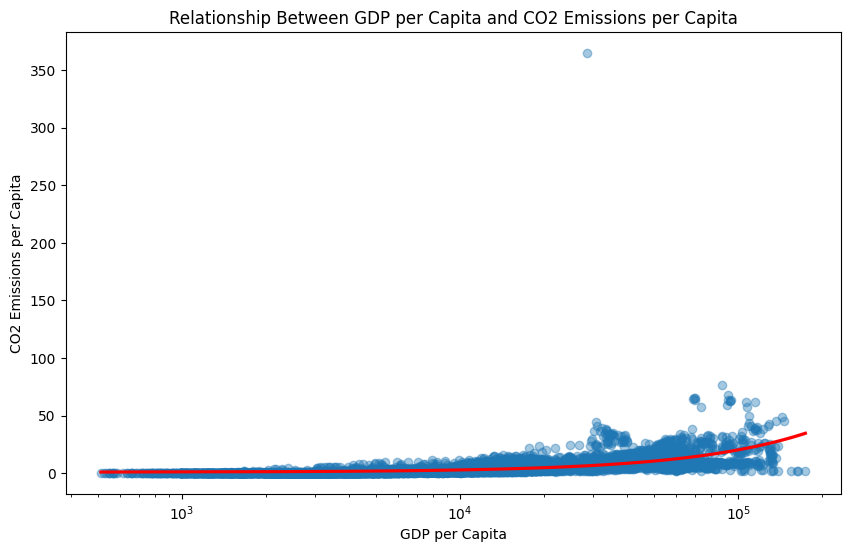

In [19]:
# Visualisation: GDP per capita vs CO2 emissions per capita


# Purpose: To visually explore the relationship between economic growth (GDP per capita) and environmental impact (CO2 emissions per capita).
# This supports the regression analysis by providing a graphical representation of the relationship.


# Method: A scatter plot is used to display individual country-year observations. A regression line is added to highlight the overall trend in the data.


import seaborn as sns
import matplotlib.pyplot as plt


# Set figure size for readability.

plt.figure(figsize=(10, 6))


# Create scatter plot with regression line.

sns.regplot(
    data=h1_df,
    x="gdp_per_capita",
    y="co2_per_capita",
    
    # Make points semi-transparent to reduce overlap.
    scatter_kws={"alpha": 0.4},
    
    # Highlight regression line clearly.
    line_kws={"color": "red"}
)


# Add descriptive title and axis labels.

plt.title("Relationship Between GDP per Capita and CO2 Emissions per Capita")
plt.xlabel("GDP per Capita")
plt.ylabel("CO2 Emissions per Capita")


# Use logarithmic scale to improve visibility (GDP values can vary widely across countries).

plt.xscale("log")


# Display the plot.

plt.show()


## Visual Interpretation

The scatter plot illustrates the relationship between GDP per capita and CO2 emissions per capita across countries and years.

An overall positive trend is observed, as indicated by the upward-sloping regression line. This suggests that higher levels of economic output are generally associated with higher emissions.

However, the data is unevenly distributed, with a large concentration of observations at lower GDP levels and a smaller number of countries with very high GDP and emissions. This results in a right-skewed distribution.

Several outliers are also present, where certain observations exhibit disproportionately high emissions. These may reflect countries with high energy consumption or reliance on carbon-intensive industries.

Despite this variability, the overall trend supports the regression findings, reinforcing the conclusion that GDP per capita is positively associated with CO2 emissions per capita.

## Summary of Findings (H1)

The analysis found a statistically significant positive relationship between GDP per capita and CO2 emissions per capita. Both the regression results and visualisation indicate that higher levels of economic output are associated with increased emissions.

The model explains approximately 32.9% of the variation in emissions, suggesting that while economic growth is an important factor, other variables also influence CO2 levels.

Overall, these findings support the hypothesis that economic growth is linked to higher carbon emissions, indicating that, within this dataset, economic development has not been fully decoupled from environmental impact.

---

# Hypothesis 2: Renewable Energy and CO2 Emissions per Capita

A key aspect of decoupling economic growth from environmental impact is the transition towards renewable energy sources. This hypothesis examines whether increased use of renewable energy is associated with lower CO2 emissions per capita, helping to assess whether cleaner energy adoption contributes to reducing emissions.

To evaluate this relationship, a **multiple linear regression model** is used. Renewable energy is included as the main independent variable, while GDP per capita is incorporated as a control variable to account for differences in economic development. CO2 emissions per capita is treated as the dependent variable. This approach allows the analysis to isolate the effect of renewable energy on emissions while considering the influence of economic activity.


## Hypothesis

- **H0 (Null):** Renewable energy is not significantly associated with CO2 emissions per capita.
- **H2 (Alternative):** Renewable energy is negatively associated with CO2 emissions per capita.



In [20]:
# H2: Multiple regression: Renewables + GDP -> CO2 emissions per capita. 


# Purpose: To test whether renewable energy is associated with lower CO2 emissions, while controlling for GDP.


# Step 1: Select relevant variables and remove missing values.

h2_df = analysis_df[[
    "renewables",
    "gdp_per_capita",
    "co2_per_capita"
]].dropna()

print(f"Number of observations used for H2: {len(h2_df)}")


# Step 2: Define independent and dependent variables.

X = h2_df[["renewables", "gdp_per_capita"]]  # predictors
y = h2_df["co2_per_capita"]                 # outcome


# Step 3: Add constant (intercept).

import statsmodels.api as sm
X = sm.add_constant(X)


# Step 4: Fit regression model.

model_h2 = sm.OLS(y, X).fit()


# Step 5: Display results.

print(model_h2.summary())

Number of observations used for H2: 6675
                            OLS Regression Results                            
Dep. Variable:         co2_per_capita   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     1635.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:14:07   Log-Likelihood:                -22062.
No. Observations:                6675   AIC:                         4.413e+04
Df Residuals:                    6672   BIC:                         4.415e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
con

## Interpretation of Results (H2)

The multiple regression analysis examined the relationship between renewable energy and CO2 emissions per capita, while controlling for GDP per capita.

The coefficient for renewable energy is positive (0.0006), but the p-value (0.424) is greater than 0.05, indicating that the relationship is not statistically significant. This suggests that there is no strong evidence that renewable energy is associated with lower CO2 emissions in this dataset.

In contrast, GDP per capita remains a statistically significant predictor (p = 0.000), with a positive coefficient, reinforcing the finding from H1 that economic growth is associated with higher emissions.

Overall, the results suggest that renewable energy alone does not have a significant independent effect on emissions when economic factors are taken into account.

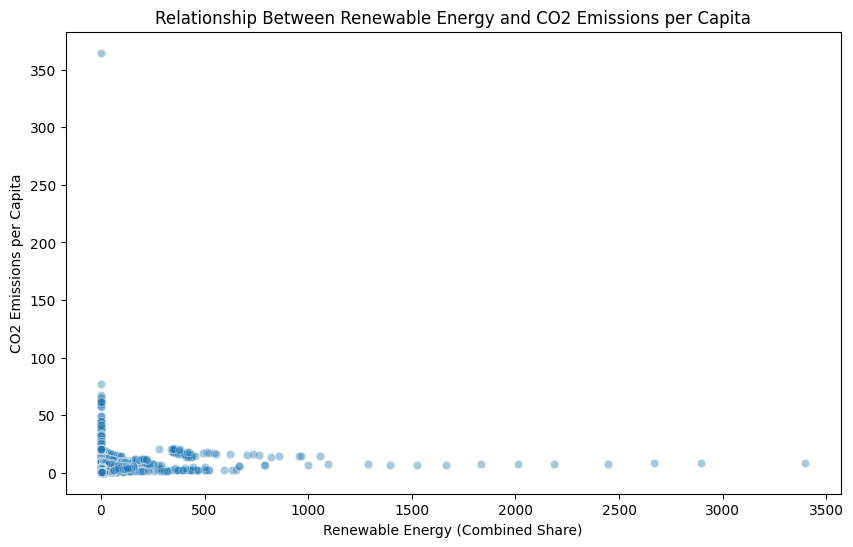

In [21]:
# Visualisation: Renewable Energy vs CO2 Emissions per Capita.


# Purpose: To visually explore whether higher levels of renewable energy are associated with lower CO2 emissions per capita.
# This helps provide an intuitive understanding of the relationship before interpreting the regression results.


# Method: A scatter plot is used to display individual country-year observations.
# Each point represents one country in a given year.
# The transparency (alpha) is reduced to help visualise dense areas where many points overlap.


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=h2_df,
    x="renewables",
    y="co2_per_capita",
    alpha=0.4
)

# Add descriptive title and labels for clarity.

plt.title("Relationship Between Renewable Energy and CO2 Emissions per Capita")
plt.xlabel("Renewable Energy (Combined Share)")
plt.ylabel("CO2 Emissions per Capita")


# Display the plot.

plt.show()

## Visual Interpretation

The scatter plot shows the relationship between renewable energy and CO2 emissions per capita.

The data points are widely dispersed, with no clear downward trend. This indicates that higher levels of renewable energy are not consistently associated with lower emissions.

A large concentration of observations is visible at lower levels of both renewable energy and emissions, while a small number of outliers exhibit unusually high values.

Overall, the visual pattern supports the regression results, suggesting that renewable energy does not have a strong independent effect on reducing CO2 emissions within this dataset.

## Summary of Findings (H2)

The results show no statistically significant relationship between renewable energy and CO2 emissions per capita when controlling for GDP per capita. While renewable energy is theoretically expected to reduce emissions, the findings suggest that its impact is not sufficient to offset the effects of economic growth within this dataset.

GDP per capita remains a strong and significant predictor of emissions, reinforcing the conclusion that economic activity continues to drive carbon output.

These findings indicate that, despite the presence of renewable energy, there is limited evidence of effective decoupling between economic growth and environmental impact. This suggests that broader structural changes, beyond increases in renewable energy alone, may be required to achieve meaningful emissions reductions.

---

# Hypothesis 3: COVID-19 Impact on CO2 Emissions per Capita

## Hypotheses

- H0: There is no difference in CO2 emissions per capita between 2019 and 2020.
- H3: CO2 emissions per capita in 2020 are lower than in 2019.

## Purpose

This analysis investigates whether the COVID-19 pandemic was associated with a significant reduction in emissions.

## Planned Method

A paired t-test will be used.

This is appropriate because the same countries are being compared across two time points: 2019 and 2020.

## Visualisation: Average CO2 Emissions per Capita in 2019 and 2020

A bar chart will be used to compare average CO2 emissions per capita before and during the COVID-19 period.

- X-axis: Year (`year`)
- Y-axis: Average CO2 emissions per capita (`co2_pc`)

This visual will support interpretation of the paired t-test results.

In [ ]:
# Placeholder code for Hypothesis 3 visualisation.
# This bar chart will compare average CO2 emissions per capita in 2019 and 2020.

# covid_avg = (
#     df_merged[df_merged["year"].isin([2019, 2020])]
#     .groupby("year", as_index=False)["co2_pc"]
#     .mean()
# )

# fig = px.bar(
#     covid_avg,
#     x="year",
#     y="co2_pc",
#     title="Average CO2 Emissions per Capita: 2019 vs 2020"
# )
# fig.show()

## Statistical Test: Paired t-test

A paired t-test will be used to compare CO2 emissions per capita for the same countries in 2019 and 2020.

This method is appropriate because it controls for country-level differences and focuses on whether emissions changed significantly between the two years.

In [ ]:
# Placeholder code for Hypothesis 3 statistical test.
# This test will compare the same countries across 2019 and 2020 once the final merged dataset is available.

# covid_data = df_merged[df_merged["year"].isin([2019, 2020])][["country_code_iso3", "year", "co2_pc"]].dropna()

# covid_pivot = covid_data.pivot(
#     index="country_code_iso3",
#     columns="year",
#     values="co2_pc"
# ).dropna()

# t_stat, p_val = ttest_rel(covid_pivot[2019], covid_pivot[2020])

# print("Paired t-test statistic:", t_stat)
# print("p-value:", p_val)

## Interpretation

If the p-value is below the chosen significance threshold, this would indicate that emissions changed significantly between 2019 and 2020.

If the average emissions in 2020 are lower than in 2019, this would support the hypothesis that emissions fell during the COVID-19 period.

---

# Hypothesis 4: CO2 Emissions per Capita by Income Group

## Hypotheses

- H0: There is no difference in CO2 emissions per capita between income groups.
- H4: There is a significant difference in CO2 emissions per capita between income groups.

## Purpose

This analysis examines whether countries in different income groups exhibit different emission patterns.

## Planned Method

An independent t-test will be used if the analysis compares two income groups.

If more than two income groups are included in the final dataset, this may be revised to a one-way ANOVA.

## Visualisation: CO2 Emissions per Capita by Income Group

A boxplot will be used to compare the distribution of CO2 emissions per capita across income groups.

- X-axis: Income group (`income_group`)
- Y-axis: CO2 emissions per capita (`co2_pc`)

A boxplot is appropriate here because it shows the median, spread, and potential outliers within each group, allowing a fuller comparison than a bar chart alone.

In [ ]:
# Placeholder code for Hypothesis 4 visualisation.
# This boxplot will compare the distribution of CO2 emissions per capita across income groups.

# fig = px.box(
#     df_merged,
#     x="income_group",
#     y="co2_pc",
#     title="CO2 Emissions per Capita by Income Group"
# )
# fig.show()

## Statistical Test: Group Comparison

The final statistical test used here will depend on how the income group variable is prepared in the merged dataset.

- If two income groups are compared, an independent t-test will be used.
- If more than two income groups are compared, a one-way ANOVA may be more appropriate.

This decision will be finalised once the merged dataset structure is confirmed.

In [ ]:
# Placeholder code for Hypothesis 4 statistical test.
# This example assumes two income groups are being compared.
# It will be adjusted if the final dataset includes more than two categories.

# group_data = df_merged[["income_group", "co2_pc"]].dropna()

# high_income = group_data[group_data["income_group"] == "High income"]["co2_pc"]
# lower_income = group_data[group_data["income_group"] == "Lower middle income"]["co2_pc"]

# t_stat, p_val = ttest_ind(high_income, lower_income, equal_var=False)

# print("Independent t-test statistic:", t_stat)
# print("p-value:", p_val)

## Interpretation

A statistically significant result would suggest that CO2 emissions per capita differ across income groups.

This would support the idea that economic position and development level influence emission patterns.

---

# Summary of Planned Hypothesis Testing

This notebook has been structured in advance to support the hypothesis testing stage once the final merged dataset becomes available.

The planned analysis includes:

- H1: Simple linear regression for GDP per capita and CO2 emissions per capita
- H2: Multiple linear regression for GDP, renewable energy, fossil fuels, and CO2 emissions per capita
- H3: Paired t-test for the COVID-19 comparison between 2019 and 2020
- H4: Income group comparison using either an independent t-test or ANOVA, depending on the final structure of the grouping variable

This preparation ensures that the statistical workflow, interpretation structure, and visualisation plan are already in place ahead of the final merged dataset.